# Detectors, filters, and count rates

`wcc_sim` addresses the instrument through `wcc_etc` *sensorfilter* strings
(`"kind:band"`). This notebook tours the two detector geometries, the available
sensorfilter keys, and the Gaia photometry → spectral type → count-rate chain.

**Requirements:** the `py313` conda env kernel. Fully offline (synthetic catalogs).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
import wcc_sim

plt.style.use('gks')
TEAL, RED, AMBER = '#00798c', '#d1495b', '#edae49'

print(f'wcc_sim {wcc_sim.__version__} | wcc_etc {wcc_etc.__version__}')

wcc_sim 0.1.0 | wcc_etc 0.6.0


## 1. The two detectors

Array dimensions live in `wcc_sim.detectors.ARRAY_DIMS` (the `wcc_etc` `Sensor` only
stores pixel area); plate scale, pixel size, and the default focus level come from the
ETC configuration.

In [2]:
from wcc_sim.detectors import ARRAY_DIMS, get_geometry

for sf in ('zwo:r', 'qcmos:bb'):
    g = get_geometry(sf)
    fov_x = g.nx * g.plate_scale_mas / 1000 / 60
    fov_y = g.ny * g.plate_scale_mas / 1000 / 60
    print(f'{sf:10s}  {g.nx} x {g.ny} px | {g.pixel_size_um:.2f} um px | '
          f'{g.plate_scale_mas:.2f} mas/px | FOV {fov_x:.2f} x {fov_y:.2f} arcmin | '
          f'default focus {g.default_focus}w')

zwo:r       9568 x 6380 px | 3.76 um px | 16.87 mas/px | FOV 2.69 x 1.79 arcmin | default focus 0w
qcmos:bb    4096 x 2304 px | 4.60 um px | 20.64 mas/px | FOV 1.41 x 0.79 arcmin | default focus 0w


## 2. Available sensorfilter keys

Each key also implies a default focus level (some keys, like `zwo:r+1`, encode it
explicitly).

In [3]:
from wcc_etc.io import _SENSORFILTER_FOCUS

for key in sorted(_SENSORFILTER_FOCUS):
    print(f'{key:12s} -> default {_SENSORFILTER_FOCUS[key]}')

qcmos:bb     -> default 0wave
qcmos:g      -> default 0wave
qcmos:i      -> default 0wave
qcmos:u      -> default 0wave
qcmos:z      -> default 0wave
zwo:bb       -> default 0wave
zwo:bb2      -> default 2wave
zwo:g        -> default 0wave
zwo:halpha   -> default 0wave
zwo:hbeta    -> default 0wave
zwo:heii     -> default 0wave
zwo:i        -> default 0wave
zwo:nii      -> default 0wave
zwo:oiii     -> default 0wave
zwo:r        -> default 0wave
zwo:r+1      -> default 1wave
zwo:r-1      -> default 1wave
zwo:u        -> default 0wave
zwo:z        -> default 0wave


## 3. BP−RP → Pickles spectral type

Each Gaia star is assigned the Pickles *dwarf* template whose color is nearest to its
BP−RP; missing colors fall back to G2V.

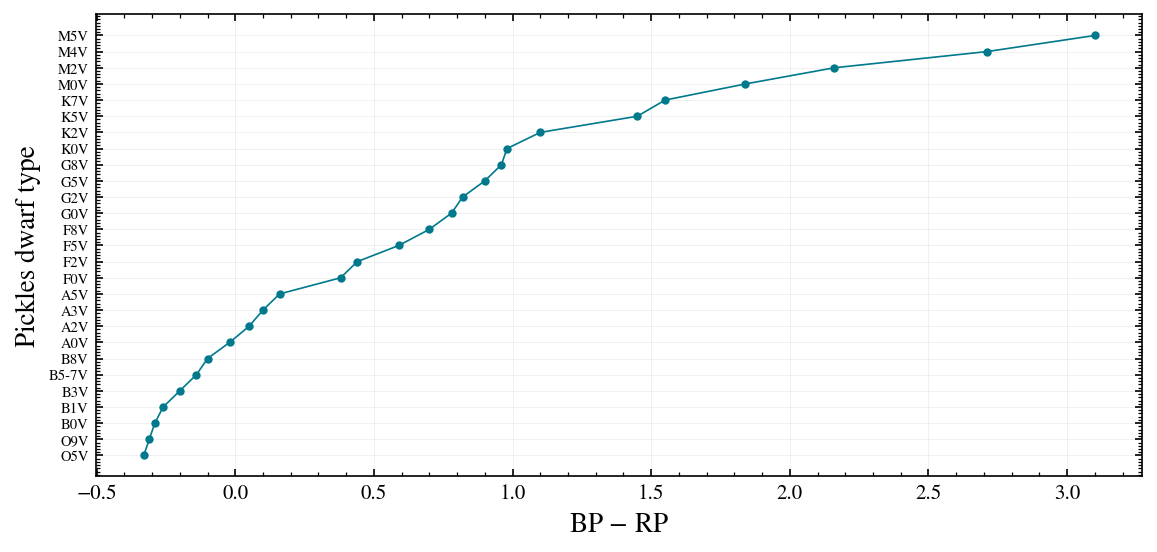

{-0.4: 'O5V', 0.0: 'A0V', 0.82: 'G2V', 1.5: 'K5V', 3.0: 'M5V', nan: 'G2V'}


In [4]:
from wcc_sim.starflux import spt_from_bp_rp, _spt_table

spts, colors = _spt_table()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(colors, np.arange(len(spts)), '.-', color=TEAL, lw=0.8)
ax.set_yticks(np.arange(len(spts)), spts, fontsize=7)
ax.set_xlabel('BP $-$ RP'); ax.set_ylabel('Pickles dwarf type')
plt.show()

demo = [-0.4, 0.0, 0.82, 1.5, 3.0, np.nan]
print(dict(zip(demo, spt_from_bp_rp(demo))))

## 4. Count rates through the instrument model

`rate_for_spt` integrates a Pickles template, normalized to G = 15 (Vega) in the Gaia
DR3 G band, through the full `wcc_etc` throughput. It is memoized per
(type, sensorfilter) — the key trick that makes full-array simulations fast.

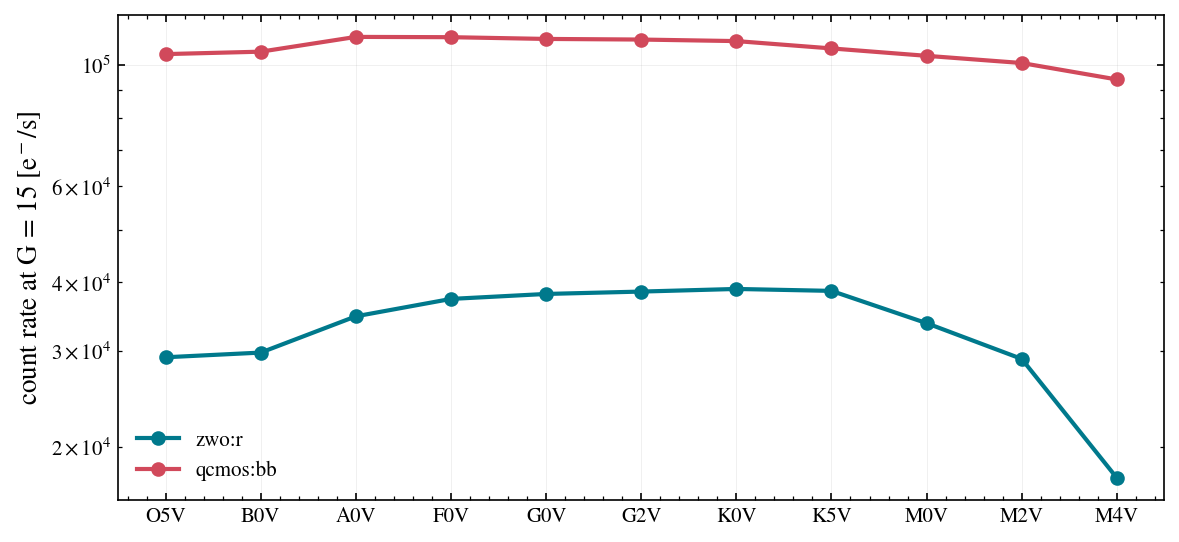

reference pin: rate_for_spt('G2V', 'zwo:r') = 38484.4 e-/s (~38484 expected)


In [5]:
from wcc_sim.starflux import rate_for_spt

types = ['O5V', 'B0V', 'A0V', 'F0V', 'G0V', 'G2V', 'K0V', 'K5V', 'M0V', 'M2V', 'M4V']
fig, ax = plt.subplots(figsize=(9, 4.2))
for sf, color in [('zwo:r', TEAL), ('qcmos:bb', RED)]:
    rates = [rate_for_spt(t, sf) for t in types]
    ax.semilogy(range(len(types)), rates, 'o-', color=color, label=sf)
ax.set_xticks(range(len(types)), types)
ax.set_ylabel('count rate at G = 15 [e$^-$/s]')
ax.legend()
plt.show()

pin = rate_for_spt('G2V', 'zwo:r')
print(f"reference pin: rate_for_spt('G2V', 'zwo:r') = {pin:.1f} e-/s (~38484 expected)")

Rates at other magnitudes are scaled analytically,
$\mathrm{rate}(G) = \mathrm{rate}(15) \times 10^{-0.4 (G - 15)}$ — exact for a fixed
spectral shape. Quick check with `rates_for_catalog`:

In [6]:
from astropy.table import Table
from wcc_sim.starflux import rates_for_catalog

cat = Table({
    'source_id': [1, 2, 3],
    'ra': [150.0] * 3, 'dec': [2.0] * 3,
    'phot_g_mean_mag': [15.0, 16.0, 17.5],
    'phot_bp_mean_mag': [15.82] * 3,       # BP-RP = 0.82 -> G2V
    'phot_rp_mean_mag': [15.0] * 3,
})
rates, spts = rates_for_catalog(cat, 'zwo:r')
print('types:', list(spts))
print('rates [e-/s]:', np.round(rates, 2))
print('measured ratios:', np.round(rates / rates[0], 6))
print('expected ratios:', np.round(10 ** (-0.4 * (cat['phot_g_mean_mag'] - 15.0)), 6))
assert np.allclose(rates / rates[0], 10 ** (-0.4 * (cat['phot_g_mean_mag'] - 15.0)))

types: ['G2V', 'G2V', 'G2V']
rates [e-/s]: [38484.39 15320.91  3848.44]
measured ratios: [1.       0.398107 0.1     ]
expected ratios: [1.       0.398107 0.1     ]


## 5. The same field on both detectors

A synthetic 5×5 star grid (G = 12–16), simulated on the IMX455 (`zwo:r`) and the qCMOS
(`qcmos:bb`). Same sky, different plate scale and pixel grid. `catalog=` bypasses the
Gaia query entirely.

In [7]:
from wcc_sim import simulate_field
from wcc_sim.wcsutil import build_wcs

RA0, DEC0 = 150.1, 2.2
SHAPE = (512, 512)

# Lay the grid out in zwo pixel space, then convert to sky coordinates.
gz = get_geometry('zwo:r')
w = build_wcs(RA0, DEC0, gz.plate_scale_mas, 0.0, SHAPE)
gx, gy = np.meshgrid(np.linspace(106, 406, 5), np.linspace(106, 406, 5))
ras, decs = w.pixel_to_world_values(gx.ravel(), gy.ravel())
n = ras.size
rng = np.random.default_rng(3)
cat = Table({
    'source_id': np.arange(n), 'ra': ras, 'dec': decs,
    'phot_g_mean_mag': rng.uniform(12, 16, n),
    'phot_bp_mean_mag': np.full(n, np.nan),   # NaN color -> G2V
    'phot_rp_mean_mag': np.full(n, np.nan),
})

fields = {}
for sf in ('zwo:r', 'qcmos:bb'):
    fields[sf] = simulate_field(RA0, DEC0, sensorfilter=sf, focus=0, exptime=90,
                                seed=11, catalog=cat, shape=SHAPE)
    p = fields[sf].params
    print(f"{sf:10s}: {p['plate_scale_mas']:.2f} mas/px | sky {p['sky_e_s']:.3f} | "
          f"dark {p['dark_e_s']:.4f} e-/s/px | read noise {p['read_noise']:.2f} e-")

zwo:r     : 16.87 mas/px | sky 0.014 | dark 0.0031 e-/s/px | read noise 3.04 e-


qcmos:bb  : 20.64 mas/px | sky 0.058 | dark 0.0500 e-/s/px | read noise 0.56 e-


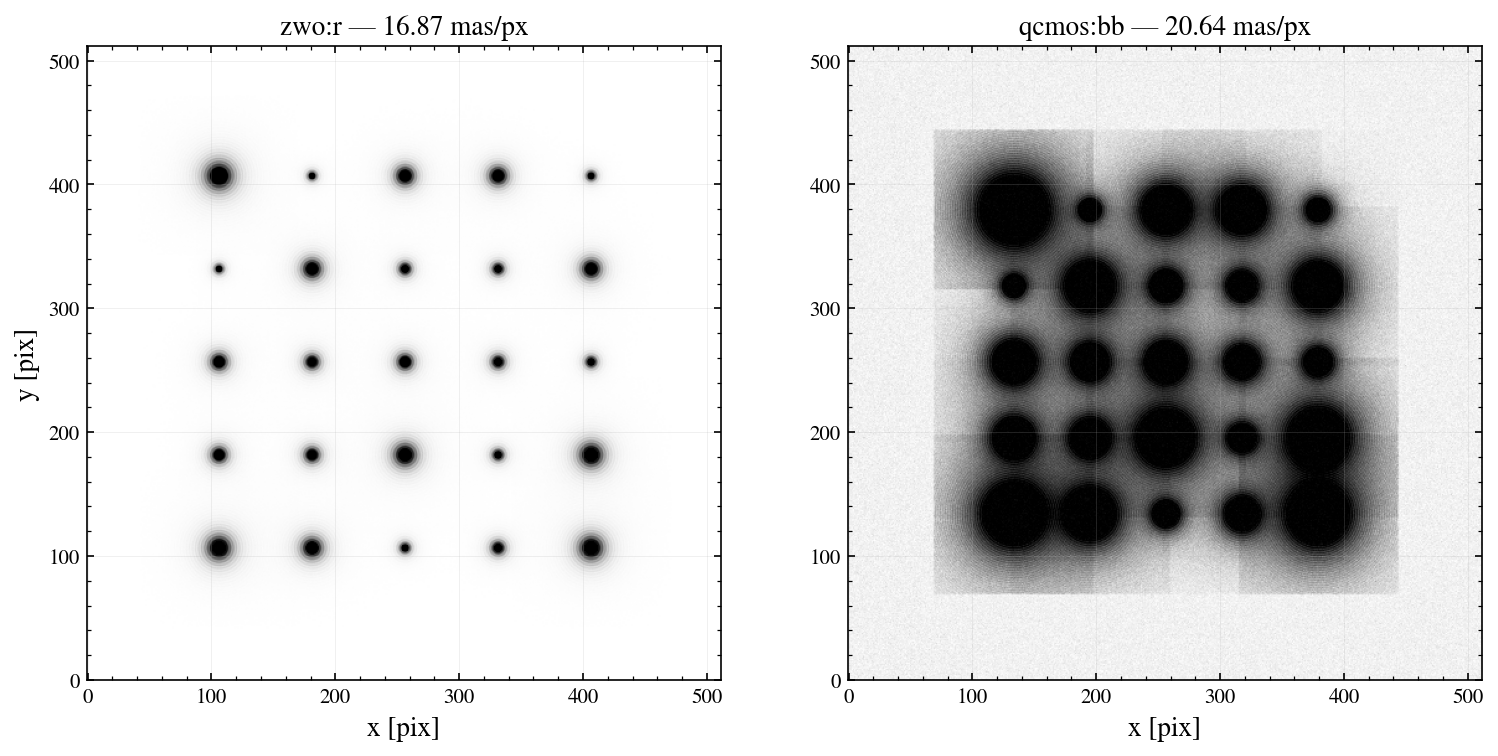

In [8]:
from astropy.visualization import simple_norm

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, sf in zip(axes, ('zwo:r', 'qcmos:bb')):
    img = fields[sf].image_adu
    ax.imshow(img, origin='lower', cmap='gray_r',
              norm=simple_norm(img, 'asinh', percent=99.7))
    scale = fields[sf].params['plate_scale_mas']
    ax.set_title(f'{sf} — {scale:.2f} mas/px')
    ax.set_xlabel('x [pix]')
axes[0].set_ylabel('y [pix]')
plt.show()

## Summary

- `zwo:*` = Sony IMX455 (9568×6380, 16.87 mas/px, 16-bit); `qcmos:*` = Hamamatsu
  HWK4123 (4096×2304, 20.64 mas/px, 12-bit).
- BP−RP picks the nearest Pickles dwarf; the rate is one synphot integration per
  (type, filter) at G = 15, scaled analytically per star.
- `catalog=` accepts any table with the six Gaia columns — the easiest way to build
  fully controlled, offline test scenes.